# 🗄️ Clase 2 — Almacenamiento y Exploración Inicial

**Curso:** Introducción a la Ciencia de Datos  
**Sesión:** 2 de 8  
**Herramientas:** Python · pandas · sqlite3 · ydata-profiling · Google Colab

---

## Objetivos de esta clase

Al terminar esta sesión vas a poder:

1. Distinguir los tipos de almacenamiento de datos y elegir el más adecuado según el contexto
2. Cargar datos en pandas desde distintos formatos (CSV, JSON, Parquet, Excel, SQLite)
3. Aplicar un protocolo de inspección inicial sistemático a cualquier dataset
4. Generar un reporte de exploración automático con `ydata-profiling`
5. Documentar las primeras observaciones sobre tu propio dataset

---

> 💡 **Recuerda:** Ejecuta las celdas en orden con `Shift + Enter`. Esta sesión tiene una parte tutorial (Secciones 1–4) y una parte práctica con tu propio dataset (Sección 5).

## ⚙️ Sección 0 — Setup

Esta celda instala las librerías que no vienen por defecto en Colab y hace todas las importaciones. Ejecútala primero — puede tomar 1-2 minutos.

In [1]:
# Instalación (solo necesaria en Colab)
# !pip install ydata-profiling --quiet

# Librerías estándar
import json
import sqlite3
import io
import os
import warnings
warnings.filterwarnings('ignore')

# Datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Profiling
from ydata_profiling import ProfileReport

# Configuración
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Setup completo. Puedes continuar.')

ModuleNotFoundError: No module named 'ydata_profiling'

---

## 🗃️ Sección 1 — Tipos de Almacenamiento

Antes de cargar datos, necesitas saber **dónde viven** los datos en la vida real. Existen cuatro grandes categorías:

---

### 1.1 Archivos planos

Son archivos que viven en un sistema de ficheros — tu computador, un servidor, Google Drive, S3.  
No tienen servidor, no tienen motor de consultas. Solo abres y lees.

| Formato | Extensión | Fortaleza | Cuándo usarlo |
|---|---|---|---|
| **CSV** | `.csv` | Universal, legible por humanos | Datasets pequeños-medianos, intercambio entre herramientas |
| **JSON** | `.json` | Jerárquico, ideal para APIs | Datos anidados, respuestas de servicios web |
| **Parquet** | `.parquet` | Columnar, comprimido, muy eficiente | Datasets grandes (>1M filas), pipelines de producción |
| **Excel** | `.xlsx` | Familiar, soporta múltiples hojas | Cuando el origen es un equipo no técnico |

```
Mismo dataset de 1 millón de filas:
  CSV     → ~150 MB  (texto plano, lento de leer)
  Parquet →  ~18 MB  (comprimido, 8× más pequeño, 10× más rápido)
```

---

### 1.2 Bases de datos relacionales (SQL)

Los datos se organizan en **tablas con relaciones entre ellas**. Se consultan con SQL. Son el estándar en aplicaciones de negocio.

```
TABLA: clientes          TABLA: pedidos
┌────┬──────────┐        ┌────┬────────────┬──────────┐
│ id │ nombre   │        │ id │ cliente_id │ monto    │
├────┼──────────┤        ├────┼────────────┼──────────┤
│  1 │ Ana      │◄───────┤  1 │          1 │ $45.000  │
│  2 │ Bruno    │        │  2 │          1 │ $12.000  │
│  3 │ Camila   │◄───────┤  3 │          3 │ $89.000  │
└────┴──────────┘        └────┴────────────┴──────────┘
         ▲
         └── La clave foránea (cliente_id) une las tablas → JOIN
```

**Ejemplos:** PostgreSQL, MySQL, SQLite (local), SQL Server, BigQuery.

---

### 1.3 Bases de datos NoSQL

Cuando los datos **no encajan bien en tablas**: son muy variados, muy grandes, o cambian de estructura frecuentemente.

| Tipo | Motor popular | Analogía | Caso de uso típico |
|---|---|---|---|
| **Documentos** | MongoDB | Cajón de carpetas JSON | Perfiles de usuario, catálogos de productos |
| **Clave-valor** | Redis | Diccionario gigante | Sesiones, caché, tiempo real |
| **Columnar** | Cassandra | Spreadsheet distribuido | Series de tiempo, IoT, logs a gran escala |
| **Grafos** | Neo4j | Red de nodos y aristas | Redes sociales, recomendaciones |

---

### 1.4 Data Lakes y Data Warehouses

```
DATA LAKE                          DATA WAREHOUSE
──────────────────────────         ──────────────────────────
"Todo entra, ya veremos"           "Solo entra lo que sirve"

📁 Datos crudos sin procesar       📊 Datos limpios y modelados
📁 Cualquier formato               📊 Esquema definido
📁 Muy barato de almacenar         📊 Optimizado para consultas
📁 Exploración, ML, archivado      📊 Reportes, dashboards, BI

Ej: S3, Google Cloud Storage       Ej: BigQuery, Snowflake, Redshift
```

> 🎯 **En este curso:** trabajaremos con **archivos planos** (CSV, JSON, Parquet, Excel) y una **base de datos SQLite local**. Son las herramientas más comunes en proyectos de análisis y el punto de entrada natural a los demás sistemas.

---

## 📥 Sección 2 — Carga de Datos con pandas

pandas tiene un conector para prácticamente cada formato. La función siempre sigue el mismo patrón:

```python
df = pd.read_<formato>("ruta/o/url")
```

Vamos a ver cada uno en acción. Para tener algo con qué trabajar, primero creamos datos de ejemplo y los guardamos en distintos formatos.

In [ ]:
# Dataset base: ventas de una tienda ficticia
# Lo usaremos para demostrar todos los formatos

np.random.seed(42)
n = 200

categorias  = ['Electrónica', 'Ropa', 'Hogar', 'Libros', 'Deportes']
ciudades    = ['Santiago', 'Valparaíso', 'Concepción', 'Antofagasta', 'Temuco']

df_ventas = pd.DataFrame({
    'id_venta':    range(1001, 1001 + n),
    'fecha':       pd.date_range('2023-01-01', periods=n, freq='D'),
    'categoria':   np.random.choice(categorias, n),
    'ciudad':      np.random.choice(ciudades, n),
    'unidades':    np.random.randint(1, 20, n),
    'precio_unit': np.random.choice([9990, 14990, 24990, 49990, 89990], n),
    'descuento':   np.random.choice([0, 5, 10, 15, 20], n),
})

df_ventas['total'] = (df_ventas['unidades'] * df_ventas['precio_unit'] *
                     (1 - df_ventas['descuento'] / 100)).astype(int)

print(f'Dataset de ventas: {df_ventas.shape[0]} filas × {df_ventas.shape[1]} columnas')
df_ventas.head(3)

Dataset de ventas: 200 filas × 8 columnas


,id_venta,fecha,categoria,ciudad,unidades,precio_unit,descuento,total
0,1001,2023-01-01,Libros,Valparaíso,16,89990,5,1367848
1,1002,2023-01-02,Deportes,Concepción,19,49990,10,854829
2,1003,2023-01-03,Hogar,Santiago,5,89990,10,404955


### 2.1 CSV — el formato universal

In [3]:
# GUARDAR como CSV
df_ventas.to_csv('ventas.csv', index=False, encoding='utf-8')
print(f'Guardado: ventas.csv ({os.path.getsize("ventas.csv") / 1024:.1f} KB)')

# CARGAR desde CSV
df_desde_csv = pd.read_csv('ventas.csv', parse_dates=['fecha'])
print(f'Cargado:  {df_desde_csv.shape[0]} filas × {df_desde_csv.shape[1]} columnas')
df_desde_csv.head(3)

Guardado: ventas.csv (10.3 KB)
Cargado:  200 filas × 8 columnas


,id_venta,fecha,categoria,ciudad,unidades,precio_unit,descuento,total
0,1001,2023-01-01,Libros,Valparaíso,16,89990,5,1367848
1,1002,2023-01-02,Deportes,Concepción,19,49990,10,854829
2,1003,2023-01-03,Hogar,Santiago,5,89990,10,404955


In [4]:
# Parámetros útiles de read_csv que conviene conocer:

# sep=';'            → cuando el separador es punto y coma (común en Chile/Europa)
# encoding='latin-1' → cuando hay problemas con acentos y ñ
# usecols=[...]      → cargar solo algunas columnas (útil en archivos enormes)
# nrows=1000         → cargar solo las primeras N filas (para exploración rápida)
# skiprows=[0,1]     → saltar filas al inicio (ej: filas de metadata del organismo)
# na_values=['N/A', '-', 'ND']  → qué valores tratar como nulos

# Ejemplo con parámetros:
df_parcial = pd.read_csv('ventas.csv',
                          usecols=['categoria', 'ciudad', 'total'],
                          nrows=10)
print('Carga parcial (3 columnas, 10 filas):')
print(df_parcial)

Carga parcial (3 columnas, 10 filas):
  categoria       ciudad    total
0    Libros   Valparaíso  1367848
1  Deportes   Concepción   854829
2     Hogar     Santiago   404955
3  Deportes     Santiago   559888
4  Deportes  Antofagasta   359960
5      Ropa   Concepción  1349850
6     Hogar       Temuco   424830
7     Hogar   Concepción  1007888
8     Hogar  Antofagasta    59960
9  Deportes  Antofagasta   254898


### 2.2 JSON — datos anidados desde APIs

In [5]:
# GUARDAR como JSON
df_ventas.to_json('ventas.json', orient='records', force_ascii=False, indent=2,
                   date_format='iso')
print(f'Guardado: ventas.json ({os.path.getsize("ventas.json") / 1024:.1f} KB)')

# CARGAR desde JSON
df_desde_json = pd.read_json('ventas.json', convert_dates=['fecha'])
print(f'Cargado:  {df_desde_json.shape[0]} filas × {df_desde_json.shape[1]} columnas')
df_desde_json.head(3)

Guardado: ventas.json (39.9 KB)
Cargado:  200 filas × 8 columnas


,id_venta,fecha,categoria,ciudad,unidades,precio_unit,descuento,total
0,1001,2023-01-01,Libros,Valparaíso,16,89990,5,1367848
1,1002,2023-01-02,Deportes,Concepción,19,49990,10,854829
2,1003,2023-01-03,Hogar,Santiago,5,89990,10,404955


In [6]:
# Caso real: JSON anidado que viene de una API
# pd.json_normalize() lo aplana automáticamente

respuesta_api = [
    {"id": 1, "producto": "Notebook",
     "tienda": {"nombre": "TechStore", "ciudad": "Santiago"},
     "metricas": {"unidades": 5, "ingreso": 449950}},
    {"id": 2, "producto": "Auriculares",
     "tienda": {"nombre": "SoundPro", "ciudad": "Valparaíso"},
     "metricas": {"unidades": 12, "ingreso": 179880}},
]

df_api = pd.json_normalize(respuesta_api)
print('JSON anidado → DataFrame plano:')
print(df_api.to_string(index=False))

JSON anidado → DataFrame plano:
 id    producto tienda.nombre tienda.ciudad  metricas.unidades  metricas.ingreso
  1    Notebook     TechStore      Santiago                  5            449950
  2 Auriculares      SoundPro    Valparaíso                 12            179880


### 2.3 Parquet — el formato eficiente

In [7]:
# Parquet requiere pyarrow o fastparquet (ya en Colab)
# GUARDAR como Parquet
df_ventas.to_parquet('ventas.parquet', index=False)

csv_size     = os.path.getsize('ventas.csv')
parquet_size = os.path.getsize('ventas.parquet')

print(f'CSV:     {csv_size / 1024:.1f} KB')
print(f'Parquet: {parquet_size / 1024:.1f} KB')
print(f'Reducción de tamaño: {(1 - parquet_size/csv_size)*100:.0f}%')
print()

# CARGAR desde Parquet
df_desde_parquet = pd.read_parquet('ventas.parquet')
print(f'Cargado: {df_desde_parquet.shape}')
df_desde_parquet.head(3)

CSV:     10.3 KB
Parquet: 9.1 KB
Reducción de tamaño: 11%

Cargado: (200, 8)


,id_venta,fecha,categoria,ciudad,unidades,precio_unit,descuento,total
0,1001,2023-01-01,Libros,Valparaíso,16,89990,5,1367848
1,1002,2023-01-02,Deportes,Concepción,19,49990,10,854829
2,1003,2023-01-03,Hogar,Santiago,5,89990,10,404955


### 2.4 Excel — cuando el cliente envía una planilla

In [8]:
# GUARDAR como Excel (con múltiples hojas)
with pd.ExcelWriter('ventas.xlsx', engine='openpyxl') as writer:
    df_ventas.to_excel(writer, sheet_name='Ventas', index=False)
    # Segunda hoja: resumen por categoría
    resumen = df_ventas.groupby('categoria')['total'].agg(['sum','mean','count'])
    resumen.columns = ['Total', 'Promedio', 'N ventas']
    resumen.to_excel(writer, sheet_name='Resumen')

print(f'Guardado: ventas.xlsx ({os.path.getsize("ventas.xlsx") / 1024:.1f} KB)')

# CARGAR una hoja específica
df_desde_excel = pd.read_excel('ventas.xlsx', sheet_name='Ventas', parse_dates=['fecha'])
print(f'Hoja "Ventas": {df_desde_excel.shape}')

# Ver qué hojas tiene el archivo
xls = pd.ExcelFile('ventas.xlsx')
print(f'Hojas disponibles: {xls.sheet_names}')

Guardado: ventas.xlsx (13.8 KB)
Hoja "Ventas": (200, 8)
Hojas disponibles: ['Ventas', 'Resumen']


### 2.5 SQLite — una base de datos relacional local

In [9]:
# SQLite crea una base de datos como un único archivo .db
# No requiere servidor — es perfecta para aprender SQL y para proyectos personales

# CREAR la base de datos y cargar datos
conn = sqlite3.connect('tienda.db')

df_ventas.to_sql('ventas', conn, if_exists='replace', index=False)

# Tabla adicional: catálogo de categorías
df_categorias = pd.DataFrame({
    'categoria':   categorias,
    'departamento': ['Tech', 'Moda', 'Casa', 'Cultura', 'Fitness'],
    'margen_obj':  [0.30, 0.45, 0.35, 0.40, 0.38]
})
df_categorias.to_sql('categorias', conn, if_exists='replace', index=False)

print('Base de datos creada: tienda.db')
print(f'Tablas disponibles:')
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tablas.to_string(index=False))

Base de datos creada: tienda.db
Tablas disponibles:
      name
    ventas
categorias


In [10]:
# LEER desde SQL — pd.read_sql() convierte el resultado directamente en DataFrame

# Consulta simple
query_simple = "SELECT * FROM ventas LIMIT 5"
df_sql = pd.read_sql(query_simple, conn)
print('=== Consulta simple ===')
print(df_sql)

=== Consulta simple ===
   id_venta                fecha categoria       ciudad  unidades  \
0      1001  2023-01-01 00:00:00    Libros   Valparaíso        16   
1      1002  2023-01-02 00:00:00  Deportes   Concepción        19   
2      1003  2023-01-03 00:00:00     Hogar     Santiago         5   
3      1004  2023-01-04 00:00:00  Deportes     Santiago        14   
4      1005  2023-01-05 00:00:00  Deportes  Antofagasta         5   

   precio_unit  descuento    total  
0        89990          5  1367848  
1        49990         10   854829  
2        89990         10   404955  
3        49990         20   559888  
4        89990         20   359960  


In [11]:
# Consulta con JOIN (unir dos tablas) y agregación
query_join = """
    SELECT
        v.categoria,
        c.departamento,
        COUNT(*)            AS n_ventas,
        SUM(v.total)        AS ingreso_total,
        AVG(v.total)        AS ticket_promedio,
        c.margen_obj * 100  AS margen_objetivo_pct
    FROM ventas v
    JOIN categorias c ON v.categoria = c.categoria
    GROUP BY v.categoria
    ORDER BY ingreso_total DESC
"""

df_join = pd.read_sql(query_join, conn)
print('=== Resumen por categoría (con JOIN) ===')
print(df_join.to_string(index=False))

=== Resumen por categoría (con JOIN) ===
  categoria departamento  n_ventas  ingreso_total  ticket_promedio  margen_objetivo_pct
     Libros      Cultura        49       15028447        306703.00                40.00
   Deportes      Fitness        36       14816667        411574.08                38.00
Electrónica         Tech        43       13785377        320590.16                30.00
      Hogar         Casa        37       13108628        354287.24                35.00
       Ropa         Moda        35       10889632        311132.34                45.00


In [12]:
# Siempre cierra la conexión cuando termines
conn.close()
print('Conexión cerrada ✅')

# --- RESUMEN: lectura rápida ---
print()
print('CHEATSHEET — Conectores pandas:')
print('  pd.read_csv("archivo.csv")                      # CSV')
print('  pd.read_json("archivo.json")                    # JSON')
print('  pd.read_parquet("archivo.parquet")              # Parquet')
print('  pd.read_excel("archivo.xlsx", sheet_name=...) # Excel')
print('  pd.read_sql("SELECT...", conn)                  # SQL')
print('  pd.read_csv("https://...")                      # URL directa')

Conexión cerrada ✅

CHEATSHEET — Conectores pandas:
  pd.read_csv("archivo.csv")                      # CSV
  pd.read_json("archivo.json")                    # JSON
  pd.read_parquet("archivo.parquet")              # Parquet
  pd.read_excel("archivo.xlsx", sheet_name=...) # Excel
  pd.read_sql("SELECT...", conn)                  # SQL
  pd.read_csv("https://...")                      # URL directa


---

## 🔍 Sección 3 — Protocolo de Inspección Inicial

Cuando recibes un dataset nuevo, siempre aplica este protocolo de 5 pasos **antes** de hacer cualquier análisis. Se tarda 5 minutos y te puede ahorrar errores más adelante.

```
PASO 1 → ¿Qué tamaño tiene?        .shape
PASO 2 → ¿Cómo se ven los datos?   .head() / .tail() / .sample()
PASO 3 → ¿Qué tipos hay?           .dtypes / .info()
PASO 4 → ¿Hay problemas?           .isnull() / .duplicated()
PASO 5 → ¿Cómo se distribuyen?     .describe() / gráficos
```

Trabajaremos con el dataset de ventas que creamos antes.

In [16]:
# Creamos una versión del dataset CON problemas típicos
# (nulos, tipos incorrectos, duplicados, inconsistencias)
# Esto simula lo que te encontrarás en datos reales

df_sucio = df_ventas.copy()

# Introducir problemas:
np.random.seed(7)
idx_nulos = np.random.choice(df_sucio.index, 25, replace=False)
df_sucio.loc[idx_nulos[:10], 'descuento'] = np.nan   # nulos en descuento
df_sucio.loc[idx_nulos[10:18], 'ciudad'] = np.nan    # nulos en ciudad
df_sucio.loc[idx_nulos[18:], 'precio_unit'] = np.nan # nulos en precio

df_sucio.loc[5, 'precio_unit'] = -9990               # precio negativo (imposible)
df_sucio.loc[12, 'unidades'] = 9999                  # outlier extremo
df_sucio['categoria'] = df_sucio['categoria'].replace(
    {'Electrónica': 'electronica', 'Ropa': 'ROPA'})  # inconsistencia de mayúsculas
df_sucio = pd.concat([df_sucio, df_sucio.iloc[:5]])  # duplicar 5 filas
df_sucio['id_venta'] = df_sucio['id_venta'].astype(str)  # id como string en vez de int
df_sucio = df_sucio.reset_index(drop=True)

print(f'Dataset con problemas: {df_sucio.shape[0]} filas × {df_sucio.shape[1]} columnas')
print('(contiene nulos, outliers, duplicados e inconsistencias)')

Dataset con problemas: 205 filas × 8 columnas
(contiene nulos, outliers, duplicados e inconsistencias)


### PASO 1 — ¿Qué tamaño tiene el dataset?

In [17]:
filas, cols = df_sucio.shape
print(f'Dimensiones:  {filas} filas × {cols} columnas')
print(f'Columnas:     {list(df_sucio.columns)}')
print(f'Memoria:      {df_sucio.memory_usage(deep=True).sum() / 1024:.1f} KB')

Dimensiones:  205 filas × 8 columnas
Columnas:     ['id_venta', 'fecha', 'categoria', 'ciudad', 'unidades', 'precio_unit', 'descuento', 'total']
Memoria:      43.5 KB


### PASO 2 — ¿Cómo se ven los datos?

In [18]:
# Primeras filas — lo que carga primero
print('=== .head(5) — primeras filas ===')
df_sucio.head(5)

=== .head(5) — primeras filas ===


,id_venta,fecha,categoria,ciudad,unidades,precio_unit,descuento,total
0,1001,2023-01-01,Libros,Valparaíso,16,89990.00,5.00,1367848
1,1002,2023-01-02,Deportes,Concepción,19,49990.00,10.00,854829
2,1003,2023-01-03,Hogar,Santiago,5,89990.00,NaN,404955
3,1004,2023-01-04,Deportes,Santiago,14,49990.00,20.00,559888
4,1005,2023-01-05,Deportes,Antofagasta,5,89990.00,20.00,359960


In [19]:
# Últimas filas — cómo termina el dataset (¿se cortó? ¿hay totales?)
print('=== .tail(5) — últimas filas ===')
df_sucio.tail(5)

=== .tail(5) — últimas filas ===


,id_venta,fecha,categoria,ciudad,unidades,precio_unit,descuento,total
200,1001,2023-01-01,Libros,Valparaíso,16,89990.00,5.00,1367848
201,1002,2023-01-02,Deportes,Concepción,19,49990.00,10.00,854829
202,1003,2023-01-03,Hogar,Santiago,5,89990.00,NaN,404955
203,1004,2023-01-04,Deportes,Santiago,14,49990.00,20.00,559888
204,1005,2023-01-05,Deportes,Antofagasta,5,89990.00,20.00,359960


In [20]:
# Muestra aleatoria — evita el sesgo de solo ver el inicio o el final
print('=== .sample(5) — muestra aleatoria ===')
df_sucio.sample(5, random_state=42)

=== .sample(5) — muestra aleatoria ===


,id_venta,fecha,categoria,ciudad,unidades,precio_unit,descuento,total
15,1016,2023-01-16,ROPA,Concepción,5,24990.00,15.00,106207
9,1010,2023-01-10,Deportes,Antofagasta,12,24990.00,15.00,254898
100,1101,2023-04-11,Libros,Temuco,5,49990.00,0.00,249950
132,1133,2023-05-13,Libros,Santiago,6,9990.00,20.00,47952
68,1069,2023-03-10,Libros,Temuco,9,49990.00,5.00,427414


### PASO 3 — ¿Qué tipos de datos hay?

In [21]:
# .info() — el resumen más completo en una sola celda
# Muestra: nombre de columna, tipo, cantidad de no-nulos
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venta     205 non-null    object        
 1   fecha        205 non-null    datetime64[ns]
 2   categoria    205 non-null    object        
 3   ciudad       197 non-null    object        
 4   unidades     205 non-null    int64         
 5   precio_unit  198 non-null    float64       
 6   descuento    194 non-null    float64       
 7   total        205 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 12.9+ KB


In [22]:
# .dtypes — rápido y limpio
print('=== Tipos por columna ===')
print(df_sucio.dtypes)

print()
print('=== ¿Qué tipos hay en este dataset? ===')
print(df_sucio.dtypes.value_counts())

print()
print('🚨 Problema detectado:')
print(f'  id_venta es "{df_sucio["id_venta"].dtype}" — debería ser int o similar')
print(f'  Ejemplo: {df_sucio["id_venta"].iloc[0]!r}')

=== Tipos por columna ===
id_venta               object
fecha          datetime64[ns]
categoria              object
ciudad                 object
unidades                int64
precio_unit           float64
descuento             float64
total                   int64
dtype: object

=== ¿Qué tipos hay en este dataset? ===
object            3
int64             2
float64           2
datetime64[ns]    1
Name: count, dtype: int64

🚨 Problema detectado:
  id_venta es "object" — debería ser int o similar
  Ejemplo: '1001'


### PASO 4 — ¿Hay problemas de calidad?

In [23]:
# 4A: Valores nulos
nulos_abs = df_sucio.isnull().sum()
nulos_pct = (nulos_abs / len(df_sucio) * 100).round(1)

reporte_nulos = pd.DataFrame({
    'Nulos': nulos_abs,
    '%': nulos_pct,
    'Tipo': df_sucio.dtypes
}).sort_values('Nulos', ascending=False)

print('=== Reporte de valores nulos ===')
print(reporte_nulos[reporte_nulos['Nulos'] > 0].to_string())
print()

total_nulos = nulos_abs.sum()
total_celdas = df_sucio.shape[0] * df_sucio.shape[1]
print(f'Total de celdas nulas: {total_nulos} de {total_celdas} ({total_nulos/total_celdas*100:.1f}%)')

=== Reporte de valores nulos ===
             Nulos    %     Tipo
descuento       11 5.40  float64
ciudad           8 3.90   object
precio_unit      7 3.40  float64

Total de celdas nulas: 26 de 1640 (1.6%)


In [24]:
# 4B: Filas duplicadas
n_duplicados = df_sucio.duplicated().sum()
print(f'Filas duplicadas encontradas: {n_duplicados}')

if n_duplicados > 0:
    print()
    print('Ejemplo de filas duplicadas:')
    mask = df_sucio.duplicated(keep=False)
    print(df_sucio[mask].sort_values('id_venta').head(4))

Filas duplicadas encontradas: 5

Ejemplo de filas duplicadas:
    id_venta      fecha categoria      ciudad  unidades  precio_unit  \
0       1001 2023-01-01    Libros  Valparaíso        16     89990.00   
200     1001 2023-01-01    Libros  Valparaíso        16     89990.00   
1       1002 2023-01-02  Deportes  Concepción        19     49990.00   
201     1002 2023-01-02  Deportes  Concepción        19     49990.00   

     descuento    total  
0         5.00  1367848  
200       5.00  1367848  
1        10.00   854829  
201      10.00   854829  


In [25]:
# 4C: Inconsistencias en columnas categóricas
print('=== Valores únicos por columna categórica ===')
for col in ['categoria', 'ciudad']:
    valores = df_sucio[col].dropna().unique()
    print(f'\n{col} ({len(valores)} valores únicos):')
    print(sorted(valores))

=== Valores únicos por columna categórica ===

categoria (5 valores únicos):
['Deportes', 'Hogar', 'Libros', 'ROPA', 'electronica']

ciudad (5 valores únicos):
['Antofagasta', 'Concepción', 'Santiago', 'Temuco', 'Valparaíso']


In [26]:
# 4D: Valores imposibles / outliers extremos en columnas numéricas
cols_numericas = ['unidades', 'precio_unit', 'descuento', 'total']

print('=== Rango de valores numéricos (min / max) ===')
for col in cols_numericas:
    mn = df_sucio[col].min()
    mx = df_sucio[col].max()
    flag = ' 🚨' if mn < 0 or mx > 5000 else ''
    print(f'  {col:<15} min={mn:>10,.0f}   max={mx:>10,.0f}{flag}')

=== Rango de valores numéricos (min / max) ===
  unidades        min=         1   max=     9,999 🚨
  precio_unit     min=    -9,990   max=    89,990 🚨
  descuento       min=         0   max=        20
  total           min=     7,992   max= 1,709,810 🚨


### PASO 5 — ¿Cómo se distribuyen los datos?

In [27]:
# .describe() para columnas numéricas
print('=== Estadísticas descriptivas (numéricas) ===')
df_ventas[['unidades', 'precio_unit', 'descuento', 'total']].describe().round(0)

=== Estadísticas descriptivas (numéricas) ===


,unidades,precio_unit,descuento,total
count,200.00,200.00,200.00,200.00
mean,10.00,37265.00,10.00,338144.00
std,6.00,30699.00,7.00,356983.00
min,1.00,9990.00,0.00,7992.00
25%,5.00,14990.00,5.00,105888.00
50%,10.00,24990.00,10.00,190917.00
75%,15.00,49990.00,15.00,427350.00
max,19.00,89990.00,20.00,1709810.00


In [28]:
# .describe() para columnas categóricas
print('=== Estadísticas descriptivas (categóricas) ===')
df_ventas[['categoria', 'ciudad']].describe()

=== Estadísticas descriptivas (categóricas) ===


,categoria,ciudad
count,200,200
unique,5,5
top,Libros,Santiago
freq,49,45


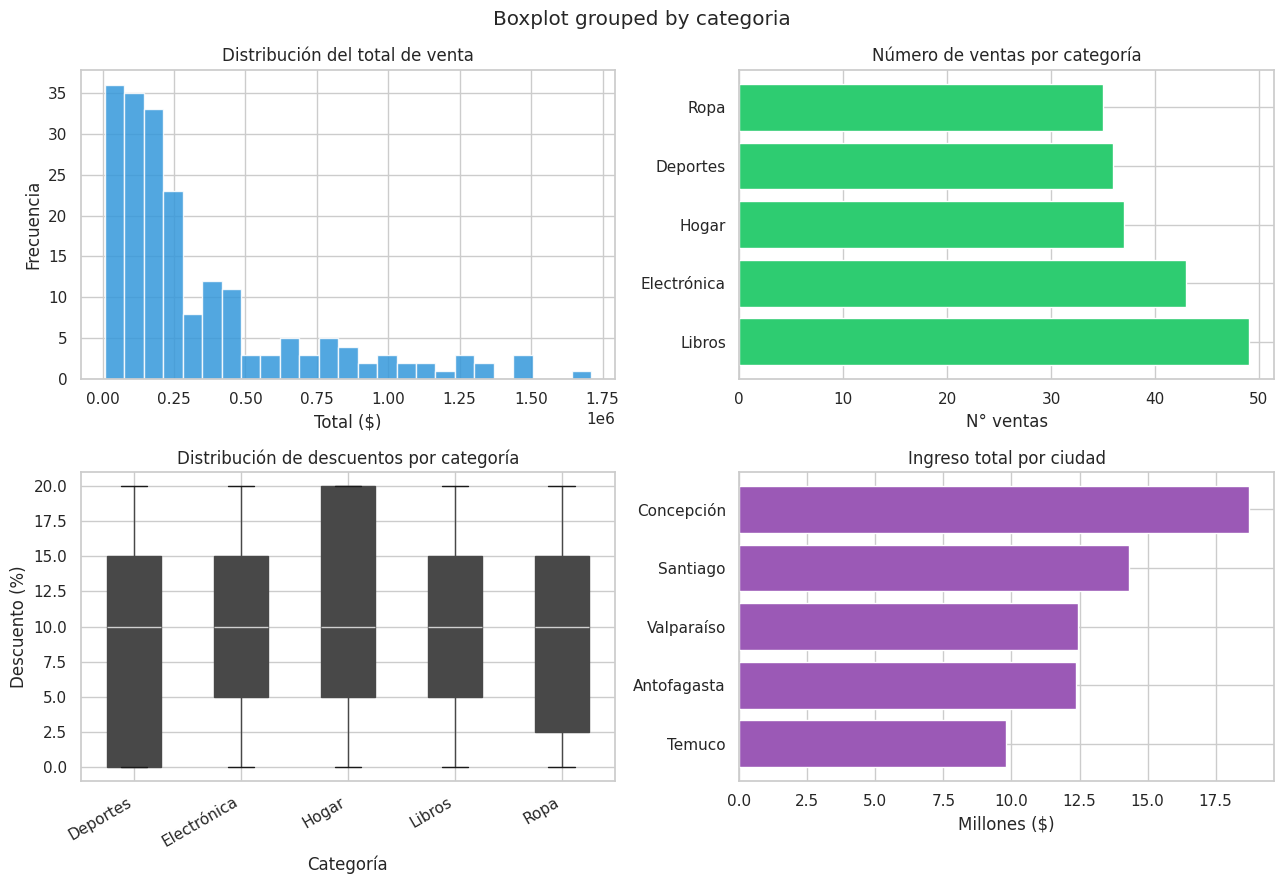

In [29]:
# Visualización de distribuciones — usando el dataset LIMPIO
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Distribuciones del dataset de ventas', fontsize=15, fontweight='bold', y=1.01)

# 1. Distribución del total de venta
axes[0,0].hist(df_ventas['total'], bins=25, color='#3498db', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Distribución del total de venta')
axes[0,0].set_xlabel('Total ($)')
axes[0,0].set_ylabel('Frecuencia')

# 2. Ventas por categoría
cat_counts = df_ventas['categoria'].value_counts()
axes[0,1].barh(cat_counts.index, cat_counts.values, color='#2ecc71', edgecolor='white')
axes[0,1].set_title('Número de ventas por categoría')
axes[0,1].set_xlabel('N° ventas')

# 3. Boxplot de descuentos por categoría
df_ventas.boxplot(column='descuento', by='categoria', ax=axes[1,0],
                  patch_artist=True, figsize=None)
axes[1,0].set_title('Distribución de descuentos por categoría')
axes[1,0].set_xlabel('Categoría')
axes[1,0].set_ylabel('Descuento (%)')
plt.sca(axes[1,0])
plt.xticks(rotation=30, ha='right')

# 4. Total acumulado por ciudad
ciudad_total = df_ventas.groupby('ciudad')['total'].sum().sort_values(ascending=True)
axes[1,1].barh(ciudad_total.index, ciudad_total.values / 1e6,
               color='#9b59b6', edgecolor='white')
axes[1,1].set_title('Ingreso total por ciudad')
axes[1,1].set_xlabel('Millones ($)')

plt.tight_layout()
plt.savefig('distribucion_ventas.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 🤖 Sección 4 — Reporte Automático con ydata-profiling

`ydata-profiling` (antes `pandas-profiling`) genera un reporte HTML interactivo completo con una sola línea. Incluye:

- Estadísticas descriptivas de cada columna
- Distribuciones visuales
- Detección de nulos, duplicados y valores extremos
- Correlaciones entre variables
- Alertas automáticas de problemas

Es ideal para la **primera exploración rápida** de un dataset nuevo.

In [30]:
# Generar el reporte (puede tomar 1-2 minutos en datasets grandes)
# Usamos el dataset CON problemas para que el reporte los detecte

print('Generando reporte... ⏳')

profile = ProfileReport(
    df_sucio,
    title='Reporte de Exploración — Dataset Ventas (con problemas)',
    explorative=True,
    minimal=False
)

# Guardar como HTML descargable
profile.to_file('reporte_ventas.html')
print('✅ Reporte guardado como reporte_ventas.html')

Generando reporte... ⏳


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 49.14it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Reporte guardado como reporte_ventas.html


In [31]:
# Mostrar el reporte embebido en el notebook
# (puede ser pesado — también puedes abrir el archivo HTML directamente)
profile.to_notebook_iframe()

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [47]:
# Si quieres descargar el archivo HTML a tu computador:
from google.colab import files
files.download('reporte_ventas.html')
# O, Puedes ir a la seccion de archivos del notebook y descargarlo directamente de ahí

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### ¿Qué buscar en el reporte?

| Sección del reporte | Qué revisar |
|---|---|
| **Overview** | Número de filas/columnas, % de celdas faltantes, duplicados |
| **Alerts** | Lista automática de alertas: alta cardinalidad, alta correlación, nulos, constantes |
| **Variables** | Por cada columna: distribución, estadísticas, valores únicos |
| **Correlations** | Heatmap de correlaciones entre variables numéricas |
| **Missing values** | Patrón de nulos — ¿son aleatorios o siguen un patrón? |
| **Duplicates** | Filas exactamente iguales |

> 💡 **Tip:** El reporte es un punto de partida, no una conclusión. Cada alerta que genera es una pregunta que debes responder con tu criterio/código.

---

## 🛠️ Sección 5 — Taller: Inspección de tu Propio Dataset

Ahora es tu turno. Carga el dataset que trajiste y aplica el protocolo de inspección completo.

**Si tu dataset está en Google Drive o lo descargaste**, usa la celda de carga. Si tienes una URL directa, úsala directamente con `pd.read_csv(url)`.

In [ ]:
# OPCIÓN A: Subir desde tu computador
from google.colab import files
uploaded = files.upload()
nombre_archivo = list(uploaded.keys())[0]
print(f'Archivo subido: {nombre_archivo}')

# Detectar formato y cargar
if nombre_archivo.endswith('.csv'):
    df_mio = pd.read_csv(nombre_archivo)
elif nombre_archivo.endswith('.json'):
    df_mio = pd.read_json(nombre_archivo)
elif nombre_archivo.endswith(('.xlsx', '.xls')):
    df_mio = pd.read_excel(nombre_archivo)
elif nombre_archivo.endswith('.parquet'):
    df_mio = pd.read_parquet(nombre_archivo)
else:
    print('Formato no reconocido. Intenta con pd.read_csv() o pd.read_excel()')

print(f'✅ Cargado: {df_mio.shape}')

In [ ]:
# OPCIÓN B: Cargar desde URL directa (si tienes el enlace)
# Descomenta y reemplaza la URL

# url_mi_dataset = 'https://...'  # ← pega aquí tu URL
# df_mio = pd.read_csv(url_mi_dataset)
# print(f'✅ Cargado: {df_mio.shape}')

In [8]:
# OPCIÓN C: Traer tu dataset de kaggle con la librería de Kaggle.
import kagglehub
path = kagglehub.dataset_download("uciml/mushroom-classification")
df_mio = pd.read_csv(os.path.join(path, "mushrooms.csv"))
print(f'✅ Cargado: {df_mio.shape}')

Using Colab cache for faster access to the 'mushroom-classification' dataset.
✅ Cargado: (8124, 23)


---

### Plantilla de inspección — aplícala a `df_mio`

Ejecuta cada celda y **completa el texto de observaciones** en las celdas Markdown marcadas con ✏️.

In [9]:
# PASO 1 — Tamaño
filas, cols = df_mio.shape
print(f'Dimensiones: {filas} filas × {cols} columnas')
print(f'Columnas: {list(df_mio.columns)}')

Dimensiones: 8124 filas × 23 columnas
Columnas: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


✏️ **Observación 1 — Tamaño:**  
*Escribe aquí: ¿el tamaño del dataset te parece suficiente para tu pregunta de investigación? ¿Hay más o menos columnas de las que esperabas?*

In [10]:
# PASO 2 — Vista de los datos
df_mio.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [11]:
df_mio.sample(5, random_state=42)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
1971,e,f,f,n,f,n,f,w,b,h,...,f,w,w,p,w,o,e,n,s,g
6654,p,f,s,e,f,y,f,c,n,b,...,s,p,p,p,w,o,e,w,v,l
5606,p,x,y,n,f,f,f,c,n,b,...,s,w,p,p,w,o,e,w,v,l
3332,e,f,y,g,t,n,f,c,b,n,...,s,g,p,p,w,o,p,n,y,d
6988,p,f,s,e,f,s,f,c,n,b,...,s,p,p,p,w,o,e,w,v,l


✏️ **Observación 2 — Primera vista:**  
*Escribe aquí: ¿entiendes qué representa cada columna? ¿Hay columnas con nombres poco claros? ¿Los valores se ven razonables a primera vista?*

In [12]:
# PASO 3 — Tipos de datos
df_mio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

✏️ **Observación 3 — Tipos de datos:**  
*Escribe aquí: ¿hay columnas numéricas que aparecen como `object`? ¿Hay fechas que no están bien tipificadas? ¿Qué columnas necesitarás convertir?*

In [13]:
# PASO 4A — Valores nulos
nulos = df_mio.isnull().sum()
pct   = (nulos / len(df_mio) * 100).round(1)
pd.DataFrame({'Nulos': nulos, '%': pct, 'Tipo': df_mio.dtypes}).sort_values('Nulos', ascending=False)

,Nulos,%,Tipo
class,0,0.00,object
cap-shape,0,0.00,object
cap-surface,0,0.00,object
cap-color,0,0.00,object
bruises,0,0.00,object
odor,0,0.00,object
gill-attachment,0,0.00,object
gill-spacing,0,0.00,object
gill-size,0,0.00,object
gill-color,0,0.00,object


In [14]:
# PASO 4B — Duplicados
n_dup = df_mio.duplicated().sum()
print(f'Filas duplicadas: {n_dup} ({n_dup/len(df_mio)*100:.1f}%)')

Filas duplicadas: 0 (0.0%)


In [15]:
# PASO 4C — Valores únicos en columnas categóricas (object)
cols_objeto = df_mio.select_dtypes('object').columns
for col in cols_objeto[:5]:  # primeras 5 para no llenar la pantalla
    n_unicos = df_mio[col].nunique()
    print(f'{col} → {n_unicos} valores únicos')
    if n_unicos <= 15:
        print(f'   {sorted(df_mio[col].dropna().unique().tolist())}')

class → 2 valores únicos
   ['e', 'p']
cap-shape → 6 valores únicos
   ['b', 'c', 'f', 'k', 's', 'x']
cap-surface → 4 valores únicos
   ['f', 'g', 's', 'y']
cap-color → 10 valores únicos
   ['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y']
bruises → 2 valores únicos
   ['f', 't']


✏️ **Observación 4 — Problemas detectados:**  
*Escribe aquí: ¿cuántos nulos hay y en qué columnas? ¿Hay duplicados? ¿Detectaste inconsistencias en los valores de texto? ¿Algún valor imposible o sospechoso?*

In [16]:
# PASO 5 — Distribución de variables numéricas
df_mio.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [17]:
# Histogramas rápidos de todas las columnas numéricas
cols_num = df_mio.select_dtypes(include='number').columns

if len(cols_num) > 0:
    n_cols_plot = min(len(cols_num), 6)
    n_filas_plot = (n_cols_plot + 1) // 2
    fig, axes = plt.subplots(n_filas_plot, 2, figsize=(12, 4 * n_filas_plot))
    axes = axes.flatten() if n_filas_plot > 1 else [axes] if n_cols_plot == 1 else axes.flatten()

    for i, col in enumerate(cols_num[:n_cols_plot]):
        df_mio[col].dropna().hist(ax=axes[i], bins=30, color='#3498db',
                                   edgecolor='white', alpha=0.85)
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_ylabel('Frecuencia')

    # Ocultar ejes vacíos
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribución de variables numéricas — Mi dataset',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No hay columnas numéricas en este dataset.')

No hay columnas numéricas en este dataset.


✏️ **Observación 5 — Distribuciones:**  
*Escribe aquí: ¿las distribuciones se ven simétricas o sesgadas? ¿Hay outliers visibles? ¿Hay variables con rango inesperado? ¿Hay variables que parecen constantes?*

In [20]:
# Generar reporte automático de TU dataset
print('Generando reporte de tu dataset... ⏳')

mi_profile = ProfileReport(
    df_mio,
    title=f'Reporte de Exploración — Mi Dataset',
    minimal=True  # minimal=True es más rápido; cámbialo a False para más detalle
)

mi_profile.to_file('mi_reporte.html')
print('✅ Guardado como mi_reporte.html')

# Descargar
files.download('mi_reporte.html')

Generando reporte de tu dataset... ⏳


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 23/23 [00:00<00:00, 33.57it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Guardado como mi_reporte.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

### Validación de tu pregunta de investigación

Después de inspeccionar el dataset, responde estas preguntas:

In [ ]:
# Completa y ejecuta esta celda — es tu ficha de validación

mi_nombre              = "Tu nombre"
mi_dataset_nombre      = "Nombre y fuente del dataset"
mi_pregunta            = "¿Cuál es tu pregunta de investigación?"
variable_objetivo      = "¿Qué columna quieres predecir o explicar?"
variables_predictoras  = "¿Qué columnas usarías como variables explicativas?"
problema_mas_urgente   = "¿Cuál es el mayor problema de calidad que encontraste?"
es_respondible         = True  # Cambia a False si crees que no es respondible con estos datos

print('='*65)
print('  FICHA DE VALIDACIÓN — SESIÓN 2')
print('='*65)
print(f'  Alumna/o:     {mi_nombre}')
print(f'  Dataset:      {mi_dataset_nombre}')
print()
print(f'  Pregunta:     {mi_pregunta}')
print(f'  Variable Y:   {variable_objetivo}')
print(f'  Variables X:  {variables_predictoras}')
print()
print(f'  Problema #1:  {problema_mas_urgente}')
print(f'  ¿Respondible? {"✅ Sí" if es_respondible else "❌ No — hay que ajustar la pregunta"}')
print('='*65)

---

## ✅ Resumen de la Clase 2

| Tema | Lo esencial |
|---|---|
| **Tipos de almacenamiento** | Archivos planos → SQL → NoSQL → Data Lake/Warehouse. Cada uno tiene su caso de uso |
| **Conectores pandas** | `read_csv`, `read_json`, `read_parquet`, `read_excel`, `read_sql`. Misma lógica, distinto formato |
| **Parquet vs CSV** | Parquet es 5–10× más pequeño y más rápido; CSV es más universal y legible |
| **SQLite** | Base de datos relacional en un solo archivo. `pd.read_sql(query, conn)` devuelve un DataFrame |
| **Protocolo de inspección** | shape → head/sample → info/dtypes → nulos/duplicados/inconsistencias → describe/gráficos |
| **ydata-profiling** | Reporte automático en una línea. Útil para primera exploración, no reemplaza el análisis |

---

**Próxima sesión — Clase 3:** Limpieza de datos. Vamos a tomar los problemas que encontraste hoy (nulos, duplicados, tipos incorrectos, outliers) y los vamos a resolver sistemáticamente.

**Tarea:** Anota en la celda de validación (Sección 5) los 3 problemas más importantes que encontraste en tu dataset. Los resolveremos juntas la próxima clase.

---
*Notebook elaborado para el curso Introducción a la Ciencia de Datos · Sesión 2*